In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all datasets
demand = pd.read_csv("../data/raw/demand_timeseries.csv", parse_dates=["date"])
specs = pd.read_csv("../data/raw/laptop_specs.csv")
bom = pd.read_csv("../data/raw/bom_table.csv")
suppliers = pd.read_csv("../data/raw/supplier_cost_table.csv")

demand.head()

,date,sku_id,units_sold
0,2022-01-01,MBA13,206
1,2022-01-02,MBA13,191
2,2022-01-03,MBA13,271
3,2022-01-04,MBA13,298
4,2022-01-05,MBA13,245


In [5]:
demand.dtypes

date          datetime64[us]
sku_id                   str
units_sold             int64
dtype: object

In [6]:
demand.shape
demand.isnull().sum()

date          0
sku_id        0
units_sold    0
dtype: int64

In [7]:
demand.groupby('sku_id')['units_sold'].describe()


,count,mean,std,min,25%,50%,75%,max
sku_id,,,,,,,,
MBA13,1461.0,287.924025,64.611328,153.0,242.0,283.0,327.0,541.0
MBA15,1096.0,243.612226,59.647627,115.0,202.0,235.0,276.0,515.0
MBP14,1096.0,184.531022,42.439847,97.0,155.0,179.0,208.0,386.0
MBP16,1096.0,110.552007,23.560416,53.0,95.0,109.0,123.0,198.0


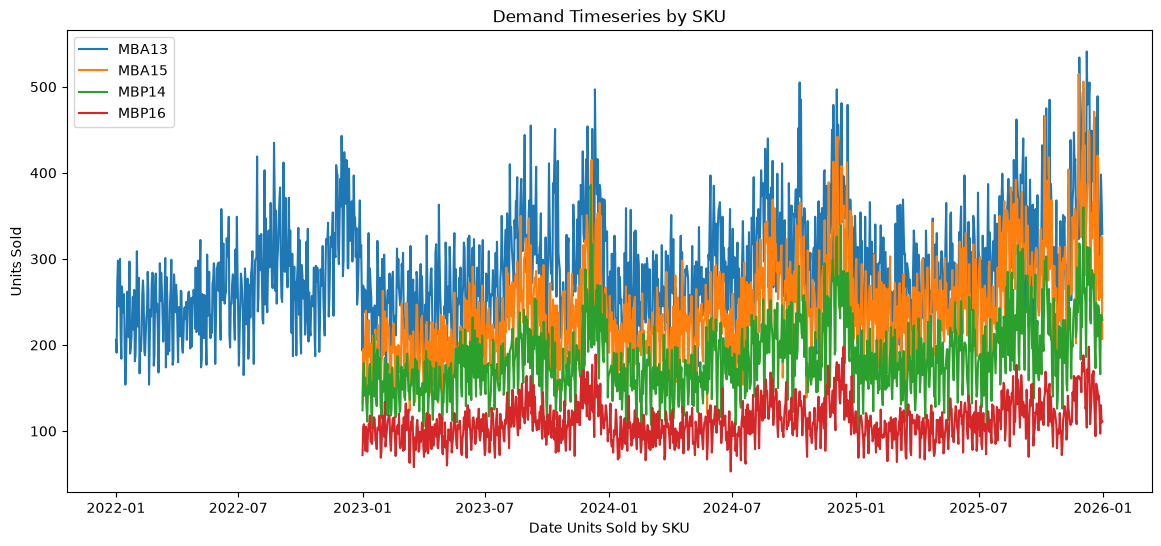

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
for sku in demand['sku_id'].unique():
    sku_data = demand[demand['sku_id'] == sku]
    ax.plot(sku_data['date'], sku_data['units_sold'], label=sku)
ax.legend()
ax.set_xlabel('Date Units Sold by SKU')
ax.set_ylabel('Units Sold')
ax.set_title('Demand Timeseries by SKU')
plt.show()

In [9]:
print(bom.groupby('sku_id')['component'].count())
suppliers.groupby('component')['supplier'].count().sort_values(ascending=False).head(10)

sku_id
MBA13     9
MBA15     9
MBP14    10
MBP16    10
Name: component, dtype: int64


component
Battery Pack (Air)         2
Battery Pack (Pro)         2
Camera Module              2
Display Panel 14in         2
Display Panel 13in         2
SSD Module                 2
RAM Module                 2
Chassis (Aluminum, Air)    1
Chassis (Aluminum, Pro)    1
Cooling Fan Assembly       1
Name: supplier, dtype: int64

In [10]:
# Extract calendar-based features
demand['year'] = demand['date'].dt.year
demand['month'] = demand['date'].dt.month
demand['day'] = demand['date'].dt.day
demand['day_of_week'] = demand['date'].dt.dayofweek  # Monday=0
demand['day_of_year'] = demand['date'].dt.dayofyear
demand['is_weekend'] = demand['day_of_week'].isin([5, 6]).astype(int)

# Seasonal flags (matching the generator's logic)
demand['is_back_to_school'] = demand['month'].isin([8, 9]).astype(int)
demand['is_holiday_season'] = demand['month'].isin([11, 12]).astype(int)

demand.head(10)

,date,sku_id,units_sold,year,month,day,day_of_week,day_of_year,is_weekend,is_back_to_school,is_holiday_season
0,2022-01-01,MBA13,206,2022,1,1,5,1,1,0,0
1,2022-01-02,MBA13,191,2022,1,2,6,2,1,0,0
2,2022-01-03,MBA13,271,2022,1,3,0,3,0,0,0
3,2022-01-04,MBA13,298,2022,1,4,1,4,0,0,0
4,2022-01-05,MBA13,245,2022,1,5,2,5,0,0,0
5,2022-01-06,MBA13,245,2022,1,6,3,6,0,0,0
6,2022-01-07,MBA13,300,2022,1,7,4,7,0,0,0
7,2022-01-08,MBA13,213,2022,1,8,5,8,1,0,0
8,2022-01-09,MBA13,184,2022,1,9,6,9,1,0,0
9,2022-01-10,MBA13,268,2022,1,10,0,10,0,0,0


In [11]:
# Sort first - lag features only make sense in chronological order
demand = demand.sort_values(['sku_id', 'date']).reset_index(drop=True)

# Lag features - grouped per SKU so we never mix products
demand['lag_1'] = demand.groupby('sku_id')['units_sold'].shift(1)
demand['lag_7'] = demand.groupby('sku_id')['units_sold'].shift(7)
demand['lag_14'] = demand.groupby('sku_id')['units_sold'].shift(14)

# Rolling averages - smoothed recent trend, also grouped per SKU
demand['rolling_mean_7'] = demand.groupby('sku_id')['units_sold'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)
demand['rolling_mean_30'] = demand.groupby('sku_id')['units_sold'].transform(
    lambda x: x.shift(1).rolling(window=30).mean()
)

demand.head(15)

,date,sku_id,units_sold,year,month,day,day_of_week,day_of_year,is_weekend,is_back_to_school,is_holiday_season,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_30
0,2022-01-01,MBA13,206,2022,1,1,5,1,1,0,0,NaN,NaN,NaN,NaN,NaN
1,2022-01-02,MBA13,191,2022,1,2,6,2,1,0,0,206.0,NaN,NaN,NaN,NaN
2,2022-01-03,MBA13,271,2022,1,3,0,3,0,0,0,191.0,NaN,NaN,NaN,NaN
3,2022-01-04,MBA13,298,2022,1,4,1,4,0,0,0,271.0,NaN,NaN,NaN,NaN
4,2022-01-05,MBA13,245,2022,1,5,2,5,0,0,0,298.0,NaN,NaN,NaN,NaN
5,2022-01-06,MBA13,245,2022,1,6,3,6,0,0,0,245.0,NaN,NaN,NaN,NaN
6,2022-01-07,MBA13,300,2022,1,7,4,7,0,0,0,245.0,NaN,NaN,NaN,NaN
7,2022-01-08,MBA13,213,2022,1,8,5,8,1,0,0,300.0,206.0,NaN,250.857143,NaN
8,2022-01-09,MBA13,184,2022,1,9,6,9,1,0,0,213.0,191.0,NaN,251.857143,NaN
9,2022-01-10,MBA13,268,2022,1,10,0,10,0,0,0,184.0,271.0,NaN,250.857143,NaN


In [12]:
print("Total rows before dropping:", demand.shape[0])
print("\nMissing values per column:")
print(demand.isnull().sum())

Total rows before dropping: 4749

Missing values per column:
date                   0
sku_id                 0
units_sold             0
year                   0
month                  0
day                    0
day_of_week            0
day_of_year            0
is_weekend             0
is_back_to_school      0
is_holiday_season      0
lag_1                  4
lag_7                 28
lag_14                56
rolling_mean_7        28
rolling_mean_30      120
dtype: int64


In [13]:
demand_clean = demand.dropna().reset_index(drop=True)

print("Rows before:", demand.shape[0])
print("Rows after:", demand_clean.shape[0])
print("Rows dropped:", demand.shape[0] - demand_clean.shape[0])

Rows before: 4749
Rows after: 4629
Rows dropped: 120


In [14]:
demand_clean.isnull().sum()

date                 0
sku_id               0
units_sold           0
year                 0
month                0
day                  0
day_of_week          0
day_of_year          0
is_weekend           0
is_back_to_school    0
is_holiday_season    0
lag_1                0
lag_7                0
lag_14               0
rolling_mean_7       0
rolling_mean_30      0
dtype: int64

In [15]:
demand_clean.groupby('sku_id')['date'].agg(['min', 'max', 'count'])

,min,max,count
sku_id,,,
MBA13,2022-01-31,2025-12-31,1431
MBA15,2023-01-31,2025-12-31,1066
MBP14,2023-01-31,2025-12-31,1066
MBP16,2023-01-31,2025-12-31,1066


In [16]:
demand_clean.dtypes

date                 datetime64[us]
sku_id                          str
units_sold                    int64
year                          int32
month                         int32
day                           int32
day_of_week                   int32
day_of_year                   int32
is_weekend                    int64
is_back_to_school             int64
is_holiday_season             int64
lag_1                       float64
lag_7                       float64
lag_14                      float64
rolling_mean_7              float64
rolling_mean_30             float64
dtype: object

In [17]:
demand_clean.to_csv("../data/processed/demand_features.csv", index=False)
print("Saved cleaned dataset:", demand_clean.shape)

Saved cleaned dataset: (4629, 16)
